## Setup and preprocessing — DDD, fresh raw load (3-DAG-split notebook)

In [2]:
import pandas as pd
import numpy as np
import os
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from dowhy import CausalModel
from econml.dml import CausalForestDML

OUTPUT_DIR = r"C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\DDD"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DATA_PATH = r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\DDD.csv"
df = pd.read_csv(DATA_PATH)

df_sel = df.copy()

df_sel['imd_band'] = df_sel['imd_band'].replace('10-20', '10-20%')
imd_mode = df_sel['imd_band'].mode()[0]
df_sel['imd_band'] = df_sel['imd_band'].fillna(imd_mode)

final_result_map = {'Withdrawn': 0, 'Fail': 1, 'Pass': 2, 'Distinction': 3}
df_sel['final_result'] = df_sel['final_result'].map(final_result_map)

highest_education_map = {
    'No Formal quals': 0, 'Lower Than A Level': 1, 'A Level or Equivalent': 2,
    'HE Qualification': 3, 'Post Graduate Qualification': 4
}
df_sel['highest_education'] = df_sel['highest_education'].map(highest_education_map)

imd_band_map = {
    '0-10%': 0, '10-20%': 1, '20-30%': 2, '30-40%': 3, '40-50%': 4,
    '50-60%': 5, '60-70%': 6, '70-80%': 7, '80-90%': 8, '90-100%': 9
}
df_sel['imd_band'] = df_sel['imd_band'].map(imd_band_map)

age_band_map = {'0-35': 0, '35-55': 1, '55<=': 2}
df_sel['age_band'] = df_sel['age_band'].map(age_band_map)

df_sel['gender'] = df_sel['gender'].map({'F': 0, 'M': 1})
df_sel['disability'] = df_sel['disability'].map({'N': 0, 'Y': 1})

le = LabelEncoder()
df_sel['region'] = le.fit_transform(df_sel['region'])

assessment_cols = [c for c in df_sel.columns if c.startswith('ass_') and c.endswith('_score')]
for col in assessment_cols:
    df_sel[col] = df_sel[col].fillna(-1)
    try:
        df_sel[col] = pd.qcut(df_sel[col], q=4, labels=False, duplicates='drop')
    except ValueError:
        pass

click_cols = [c for c in df_sel.columns if c.startswith('clicks_')]
for col in click_cols:
    df_sel[col] = df_sel[col].fillna(0)

print(df_sel.shape)
df_sel.isna().sum().sum()

(4969, 37)


np.int64(17468)

## DAG1 — Demographics vs final_result — build graph, derive adjustment sets, run ATE + refutation

In [7]:
dag1_edges = [
    ('gender', 'age_band'),
    ('gender', 'studied_credits'),
    ('gender', 'disability'),
    ('highest_education', 'region'),
    ('imd_band', 'region'),
    ('disability', 'region'),
    ('age_band', 'highest_education'),
    ('highest_education', 'disability'),
    ('highest_education', 'final_result'),
    ('imd_band', 'final_result'),
    ('num_of_prev_attempts', 'disability'),
    ('num_of_prev_attempts', 'final_result'),
    ('disability', 'final_result'),
]

G1 = nx.DiGraph()
G1.add_edges_from(dag1_edges)

dag1_treatments = [n for n in G1.nodes() if n != 'final_result' and nx.has_path(G1, n, 'final_result')]
print("DAG1 treatments:", dag1_treatments)

dag1_adjustment_sets = {t: list(G1.predecessors(t)) for t in dag1_treatments}
for t, adj in dag1_adjustment_sets.items():
    print(t, "->", adj)

DAG1 treatments: ['gender', 'age_band', 'disability', 'highest_education', 'imd_band', 'num_of_prev_attempts']
gender -> []
age_band -> ['gender']
disability -> ['gender', 'highest_education', 'num_of_prev_attempts']
highest_education -> ['age_band']
imd_band -> []
num_of_prev_attempts -> []


## DAG1 — ATE loop with refutation

In [10]:
dag1_results = []
dag1_refutation = []

for treatment in dag1_treatments:
    common_causes = dag1_adjustment_sets[treatment]

    model = CausalModel(
        data=df_sel,
        treatment=treatment,
        outcome='final_result',
        common_causes=common_causes if len(common_causes) > 0 else None
    )
    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression",
        confidence_intervals=True
    )

    ate = estimate.value
    ci = estimate.get_confidence_intervals()
    ci_low, ci_high = ci[0][0], ci[0][1]
    significant = not (ci_low <= 0 <= ci_high)

    dag1_results.append({
        'DAG': 1, 'treatment': treatment, 'adjustment_set': common_causes,
        'ATE': ate, 'CI_lower': ci_low, 'CI_upper': ci_high, 'significant': significant
    })

    placebo_refute = model.refute_estimate(identified_estimand, estimate,
                                            method_name="placebo_treatment_refuter", placebo_type="permute")
    random_cause_refute = model.refute_estimate(identified_estimand, estimate,
                                                 method_name="random_common_cause")

    dag1_refutation.append({
        'treatment': treatment, 'original_ATE': ate,
        'placebo_new_effect': placebo_refute.new_effect,
        'random_cause_diff': abs(random_cause_refute.new_effect - ate)
    })

    print(f"{treatment}: ATE={ate:.3f}, CI=[{ci_low:.3f}, {ci_high:.3f}], significant={significant}")

dag1_results_df = pd.DataFrame(dag1_results)
dag1_refutation_df = pd.DataFrame(dag1_refutation)
dag1_results_df

gender: ATE=0.113, CI=[0.057, 0.169], significant=True
age_band: ATE=0.111, CI=[0.052, 0.171], significant=True
disability: ATE=-0.212, CI=[-0.296, -0.128], significant=True
highest_education: ATE=0.191, CI=[0.154, 0.228], significant=True
imd_band: ATE=0.049, CI=[0.039, 0.059], significant=True
num_of_prev_attempts: ATE=-0.189, CI=[-0.237, -0.141], significant=True


,DAG,treatment,adjustment_set,ATE,CI_lower,CI_upper,significant
0,1,gender,[],0.112907,0.057072,0.168741,True
1,1,age_band,[gender],0.111475,0.052188,0.170762,True
2,1,disability,"[gender, highest_education, num_of_prev_attempts]",-0.211888,-0.295503,-0.128274,True
3,1,highest_education,[age_band],0.191116,0.153949,0.228282,True
4,1,imd_band,[],0.048638,0.038726,0.058550,True
5,1,num_of_prev_attempts,[],-0.188779,-0.236952,-0.140606,True


## DAG1 — refutation check

In [13]:
dag1_refutation_df

,treatment,original_ATE,placebo_new_effect,random_cause_diff
0,gender,0.112907,-0.002624,0.000014
1,age_band,0.111475,-0.004701,0.000005
2,disability,-0.211888,-0.001223,0.000049
3,highest_education,0.191116,-0.001229,0.000026
4,imd_band,0.048638,-0.000178,0.000003
5,num_of_prev_attempts,-0.188779,-0.000809,0.000031


## DAG2 — Assessments vs final_result — build graph, derive adjustment sets, run ATE + refutation

In [16]:
dag2_edges = [
    ('ass_1_score', 'ass_2_score'), ('ass_1_score', 'ass_3_score'), ('ass_1_score', 'ass_4_score'),
    ('ass_1_score', 'ass_5_score'), ('ass_1_score', 'ass_7_score'), ('ass_1_score', 'final_result'),
    ('ass_2_score', 'ass_3_score'), ('ass_2_score', 'ass_4_score'), ('ass_2_score', 'ass_5_score'),
    ('ass_3_score', 'ass_4_score'), ('ass_3_score', 'ass_5_score'), ('ass_3_score', 'ass_7_score'),
    ('ass_3_score', 'final_result'),
    ('ass_4_score', 'ass_5_score'), ('ass_4_score', 'ass_6_score'), ('ass_4_score', 'ass_7_score'),
    ('ass_4_score', 'final_result'),
    ('ass_5_score', 'ass_6_score'), ('ass_5_score', 'final_result'),
    ('ass_6_score', 'final_result'),
    ('ass_7_score', 'final_result'),
]

G2 = nx.DiGraph()
G2.add_edges_from(dag2_edges)

dag2_treatments = [n for n in G2.nodes() if n != 'final_result' and nx.has_path(G2, n, 'final_result')]
print("DAG2 treatments:", dag2_treatments)

dag2_adjustment_sets = {t: list(G2.predecessors(t)) for t in dag2_treatments}
for t, adj in dag2_adjustment_sets.items():
    print(t, "->", adj)

DAG2 treatments: ['ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_5_score', 'ass_7_score', 'ass_6_score']
ass_1_score -> []
ass_2_score -> ['ass_1_score']
ass_3_score -> ['ass_1_score', 'ass_2_score']
ass_4_score -> ['ass_1_score', 'ass_2_score', 'ass_3_score']
ass_5_score -> ['ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score']
ass_7_score -> ['ass_1_score', 'ass_3_score', 'ass_4_score']
ass_6_score -> ['ass_4_score', 'ass_5_score']


## DAG2 — ATE loop with refutation

In [19]:
dag2_results = []
dag2_refutation = []

for treatment in dag2_treatments:
    common_causes = dag2_adjustment_sets[treatment]

    model = CausalModel(
        data=df_sel,
        treatment=treatment,
        outcome='final_result',
        common_causes=common_causes if len(common_causes) > 0 else None
    )
    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression",
        confidence_intervals=True
    )

    ate = estimate.value
    ci = estimate.get_confidence_intervals()
    ci_low, ci_high = ci[0][0], ci[0][1]
    significant = not (ci_low <= 0 <= ci_high)

    dag2_results.append({
        'DAG': 2, 'treatment': treatment, 'adjustment_set': common_causes,
        'ATE': ate, 'CI_lower': ci_low, 'CI_upper': ci_high, 'significant': significant
    })

    placebo_refute = model.refute_estimate(identified_estimand, estimate,
                                            method_name="placebo_treatment_refuter", placebo_type="permute")
    random_cause_refute = model.refute_estimate(identified_estimand, estimate,
                                                 method_name="random_common_cause")

    dag2_refutation.append({
        'treatment': treatment, 'original_ATE': ate,
        'placebo_new_effect': placebo_refute.new_effect,
        'random_cause_diff': abs(random_cause_refute.new_effect - ate)
    })

    print(f"{treatment}: ATE={ate:.3f}, CI=[{ci_low:.3f}, {ci_high:.3f}], significant={significant}")

dag2_results_df = pd.DataFrame(dag2_results)
dag2_refutation_df = pd.DataFrame(dag2_refutation)
dag2_results_df

ass_1_score: ATE=0.536, CI=[0.517, 0.556], significant=True
ass_2_score: ATE=0.472, CI=[0.436, 0.507], significant=True
ass_3_score: ATE=0.491, CI=[0.455, 0.526], significant=True
ass_4_score: ATE=0.548, CI=[0.514, 0.581], significant=True
ass_5_score: ATE=0.508, CI=[0.477, 0.539], significant=True
ass_7_score: ATE=0.618, CI=[0.567, 0.668], significant=True
ass_6_score: ATE=0.243, CI=[0.191, 0.296], significant=True


,DAG,treatment,adjustment_set,ATE,CI_lower,CI_upper,significant
0,2,ass_1_score,[],0.536220,0.516636,0.555803,True
1,2,ass_2_score,[ass_1_score],0.471788,0.436184,0.507392,True
2,2,ass_3_score,"[ass_1_score, ass_2_score]",0.490678,0.455483,0.525873,True
3,2,ass_4_score,"[ass_1_score, ass_2_score, ass_3_score]",0.547779,0.514183,0.581374,True
4,2,ass_5_score,"[ass_1_score, ass_2_score, ass_3_score, ass_4_...",0.508345,0.477250,0.539440,True
5,2,ass_7_score,"[ass_1_score, ass_3_score, ass_4_score]",0.617596,0.566855,0.668338,True
6,2,ass_6_score,"[ass_4_score, ass_5_score]",0.243367,0.190883,0.295852,True


In [21]:
dag2_refutation_df

,treatment,original_ATE,placebo_new_effect,random_cause_diff
0,ass_1_score,0.536220,-0.002001,0.000001
1,ass_2_score,0.471788,-0.000369,0.000011
2,ass_3_score,0.490678,0.000634,0.000014
3,ass_4_score,0.547779,-0.000579,0.000029
4,ass_5_score,0.508345,0.001947,0.000022
5,ass_7_score,0.617596,0.000418,0.000004
6,ass_6_score,0.243367,-0.000088,0.000046


## DAG3 — Individual clicks vs final_result — fresh pull from raw df, re-bin, build graph, run ATE + refutation

In [24]:
click_cols_dag3 = ['clicks_externalquiz', 'clicks_forumng', 'clicks_glossary', 'clicks_homepage',
                    'clicks_oucollaborate', 'clicks_oucontent', 'clicks_ouwiki', 'clicks_resource',
                    'clicks_subpage', 'clicks_url']

df_dag3 = df_sel[click_cols_dag3 + ['final_result']].copy()

for col in click_cols_dag3:
    try:
        df_dag3[col] = pd.qcut(df_dag3[col], q=4, labels=False, duplicates='drop')
    except ValueError as e:
        print(f"{col}: binning issue -> {e}")

for col in click_cols_dag3:
    print(col, df_dag3[col].nunique(), "bins")

clicks_externalquiz 4 bins
clicks_forumng 4 bins
clicks_glossary 2 bins
clicks_homepage 4 bins
clicks_oucollaborate 3 bins
clicks_oucontent 4 bins
clicks_ouwiki 2 bins
clicks_resource 4 bins
clicks_subpage 4 bins
clicks_url 4 bins


## DAG3 — build graph, derive adjustment sets, run ATE + refutation

In [27]:
dag3_edges = [
    ('clicks_externalquiz', 'clicks_homepage'),
    ('clicks_oucollaborate', 'clicks_externalquiz'),
    ('clicks_externalquiz', 'clicks_resource'),
    ('clicks_subpage', 'clicks_externalquiz'),
    ('clicks_externalquiz', 'clicks_url'),
    ('clicks_externalquiz', 'final_result'),
    ('clicks_homepage', 'clicks_forumng'),
    ('clicks_oucollaborate', 'clicks_forumng'),
    ('clicks_oucontent', 'clicks_forumng'),
    ('clicks_ouwiki', 'clicks_forumng'),
    ('clicks_subpage', 'clicks_forumng'),
    ('clicks_url', 'clicks_forumng'),
    ('clicks_glossary', 'clicks_ouwiki'),
    ('clicks_oucollaborate', 'clicks_homepage'),
    ('clicks_oucontent', 'clicks_homepage'),
    ('clicks_ouwiki', 'clicks_homepage'),
    ('clicks_homepage', 'clicks_resource'),
    ('clicks_subpage', 'clicks_homepage'),
    ('clicks_url', 'clicks_homepage'),
    ('clicks_homepage', 'final_result'),
    ('clicks_oucollaborate', 'clicks_resource'),
    ('clicks_oucollaborate', 'clicks_url'),
    ('clicks_oucollaborate', 'final_result'),
    ('clicks_oucontent', 'clicks_resource'),
    ('clicks_oucontent', 'clicks_url'),
    ('clicks_oucontent', 'final_result'),
    ('clicks_subpage', 'clicks_ouwiki'),
    ('clicks_ouwiki', 'final_result'),
    ('clicks_subpage', 'clicks_resource'),
    ('clicks_url', 'clicks_resource'),
    ('clicks_resource', 'final_result'),
    ('clicks_subpage', 'clicks_url'),
    ('clicks_subpage', 'final_result'),
]
# Undirected pairs (TAIL-TAIL): clicks_glossary--clicks_resource, clicks_oucontent--clicks_subpage
dag3_undirected = [('clicks_glossary', 'clicks_resource'), ('clicks_oucontent', 'clicks_subpage')]

G3 = nx.DiGraph()
G3.add_edges_from(dag3_edges)

dag3_treatments = [n for n in G3.nodes() if n != 'final_result' and nx.has_path(G3, n, 'final_result')]
print("DAG3 treatments:", dag3_treatments)

dag3_adjustment_sets = {t: list(G3.predecessors(t)) for t in dag3_treatments}
for t, adj in dag3_adjustment_sets.items():
    print(t, "->", adj)

DAG3 treatments: ['clicks_externalquiz', 'clicks_homepage', 'clicks_oucollaborate', 'clicks_resource', 'clicks_subpage', 'clicks_url', 'clicks_oucontent', 'clicks_ouwiki', 'clicks_glossary']
clicks_externalquiz -> ['clicks_oucollaborate', 'clicks_subpage']
clicks_homepage -> ['clicks_externalquiz', 'clicks_oucollaborate', 'clicks_oucontent', 'clicks_ouwiki', 'clicks_subpage', 'clicks_url']
clicks_oucollaborate -> []
clicks_resource -> ['clicks_externalquiz', 'clicks_homepage', 'clicks_oucollaborate', 'clicks_oucontent', 'clicks_subpage', 'clicks_url']
clicks_subpage -> []
clicks_url -> ['clicks_externalquiz', 'clicks_oucollaborate', 'clicks_oucontent', 'clicks_subpage']
clicks_oucontent -> []
clicks_ouwiki -> ['clicks_glossary', 'clicks_subpage']
clicks_glossary -> []


## DAG3 — ATE loop with refutation

In [30]:
dag3_results = []
dag3_refutation = []

for treatment in dag3_treatments:
    common_causes = dag3_adjustment_sets[treatment]

    model = CausalModel(
        data=df_dag3,
        treatment=treatment,
        outcome='final_result',
        common_causes=common_causes if len(common_causes) > 0 else None
    )
    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression",
        confidence_intervals=True
    )

    ate = estimate.value
    ci = estimate.get_confidence_intervals()
    ci_low, ci_high = ci[0][0], ci[0][1]
    significant = not (ci_low <= 0 <= ci_high)

    dag3_results.append({
        'DAG': 3, 'treatment': treatment, 'adjustment_set': common_causes,
        'ATE': ate, 'CI_lower': ci_low, 'CI_upper': ci_high, 'significant': significant
    })

    placebo_refute = model.refute_estimate(identified_estimand, estimate,
                                            method_name="placebo_treatment_refuter", placebo_type="permute")
    random_cause_refute = model.refute_estimate(identified_estimand, estimate,
                                                 method_name="random_common_cause")

    dag3_refutation.append({
        'treatment': treatment, 'original_ATE': ate,
        'placebo_new_effect': placebo_refute.new_effect,
        'random_cause_diff': abs(random_cause_refute.new_effect - ate)
    })

    print(f"{treatment}: ATE={ate:.3f}, CI=[{ci_low:.3f}, {ci_high:.3f}], significant={significant}")

dag3_results_df = pd.DataFrame(dag3_results)
dag3_refutation_df = pd.DataFrame(dag3_refutation)
dag3_results_df

clicks_externalquiz: ATE=0.146, CI=[0.119, 0.173], significant=True
clicks_homepage: ATE=0.147, CI=[0.104, 0.190], significant=True
clicks_oucollaborate: ATE=0.686, CI=[0.658, 0.713], significant=True
clicks_resource: ATE=0.149, CI=[0.111, 0.187], significant=True
clicks_subpage: ATE=0.578, CI=[0.560, 0.597], significant=True
clicks_url: ATE=-0.030, CI=[-0.065, 0.006], significant=False
clicks_oucontent: ATE=0.490, CI=[0.470, 0.510], significant=True
clicks_ouwiki: ATE=0.230, CI=[0.173, 0.287], significant=True
clicks_glossary: ATE=0.578, CI=[0.516, 0.641], significant=True


,DAG,treatment,adjustment_set,ATE,CI_lower,CI_upper,significant
0,3,clicks_externalquiz,"[clicks_oucollaborate, clicks_subpage]",0.146013,0.119124,0.172902,True
1,3,clicks_homepage,"[clicks_externalquiz, clicks_oucollaborate, cl...",0.146917,0.103888,0.189945,True
2,3,clicks_oucollaborate,[],0.685592,0.658403,0.712781,True
3,3,clicks_resource,"[clicks_externalquiz, clicks_homepage, clicks_...",0.149196,0.111270,0.187123,True
4,3,clicks_subpage,[],0.578076,0.559607,0.596544,True
5,3,clicks_url,"[clicks_externalquiz, clicks_oucollaborate, cl...",-0.029634,-0.064794,0.005526,False
6,3,clicks_oucontent,[],0.489932,0.469586,0.510278,True
7,3,clicks_ouwiki,"[clicks_glossary, clicks_subpage]",0.230079,0.172668,0.287489,True
8,3,clicks_glossary,[],0.578284,0.515581,0.640986,True


In [32]:
dag3_refutation_df

,treatment,original_ATE,placebo_new_effect,random_cause_diff
0,clicks_externalquiz,0.146013,-0.000002,0.000014
1,clicks_homepage,0.146917,-0.000234,0.000017
2,clicks_oucollaborate,0.685592,-0.002032,0.000018
3,clicks_resource,0.149196,-0.000635,0.000027
4,clicks_subpage,0.578076,0.000364,0.000024
5,clicks_url,-0.029634,-0.000172,0.000010
6,clicks_oucontent,0.489932,-0.000747,0.000007
7,clicks_ouwiki,0.230079,0.003266,0.000064
8,clicks_glossary,0.578284,0.007511,0.000034


## CATE — DAG2 (assessments) only, age_band and imd_band pulled back from raw df

In [35]:
df_dag2_cate = df_sel[dag2_treatments + ['final_result', 'age_band', 'imd_band']].copy()

dag2_cate_results = []
moderators = ['age_band', 'imd_band']

for treatment in dag2_treatments:
    adj_set = dag2_adjustment_sets[treatment]

    for moderator in moderators:
        if treatment == moderator:
            continue

        W_cols = [c for c in adj_set if c != moderator]

        X = df_dag2_cate[[moderator]].values
        T = df_dag2_cate[treatment].values
        Y = df_dag2_cate['final_result'].values
        W = df_dag2_cate[W_cols].values if len(W_cols) > 0 else None

        est = CausalForestDML(random_state=42)
        est.fit(Y, T, X=X, W=W)

        cate_values = est.effect(X)

        dag2_cate_results.append({
            'treatment': treatment, 'moderator': moderator, 'W_cols': W_cols,
            'CATE_mean': cate_values.mean(), 'CATE_min': cate_values.min(),
            'CATE_max': cate_values.max(), 'CATE_std': cate_values.std()
        })

        print(f"{treatment} | moderator={moderator}: mean={cate_values.mean():.3f}, std={cate_values.std():.3f}")

dag2_cate_df = pd.DataFrame(dag2_cate_results)
dag2_cate_df

ass_1_score | moderator=age_band: mean=0.536, std=0.005
ass_1_score | moderator=imd_band: mean=0.527, std=0.039
ass_2_score | moderator=age_band: mean=0.475, std=0.011
ass_2_score | moderator=imd_band: mean=0.461, std=0.043
ass_3_score | moderator=age_band: mean=0.488, std=0.005
ass_3_score | moderator=imd_band: mean=0.492, std=0.052
ass_4_score | moderator=age_band: mean=0.517, std=0.005
ass_4_score | moderator=imd_band: mean=0.545, std=0.052
ass_5_score | moderator=age_band: mean=0.508, std=0.047
ass_5_score | moderator=imd_band: mean=0.512, std=0.079
ass_7_score | moderator=age_band: mean=0.681, std=0.037
ass_7_score | moderator=imd_band: mean=0.612, std=0.093
ass_6_score | moderator=age_band: mean=0.401, std=0.054
ass_6_score | moderator=imd_band: mean=0.403, std=0.068


,treatment,moderator,W_cols,CATE_mean,CATE_min,CATE_max,CATE_std
0,ass_1_score,age_band,[],0.535866,0.527242,0.538721,0.004962
1,ass_1_score,imd_band,[],0.527194,0.461145,0.595357,0.038606
2,ass_2_score,age_band,[ass_1_score],0.474536,0.455073,0.480980,0.011199
3,ass_2_score,imd_band,[ass_1_score],0.461081,0.369162,0.522544,0.042697
4,ass_3_score,age_band,"[ass_1_score, ass_2_score]",0.487583,0.478742,0.490510,0.005087
5,ass_3_score,imd_band,"[ass_1_score, ass_2_score]",0.491655,0.412157,0.576322,0.051836
6,ass_4_score,age_band,"[ass_1_score, ass_2_score, ass_3_score]",0.516822,0.507764,0.519821,0.005212
7,ass_4_score,imd_band,"[ass_1_score, ass_2_score, ass_3_score]",0.545161,0.481502,0.677903,0.052192
8,ass_5_score,age_band,"[ass_1_score, ass_2_score, ass_3_score, ass_4_...",0.507974,0.481017,0.589389,0.046847
9,ass_5_score,imd_band,"[ass_1_score, ass_2_score, ass_3_score, ass_4_...",0.511602,0.356811,0.602453,0.079253


## CATE point + 95% CI plots by moderator bin — DAG2 treatments, saved individually

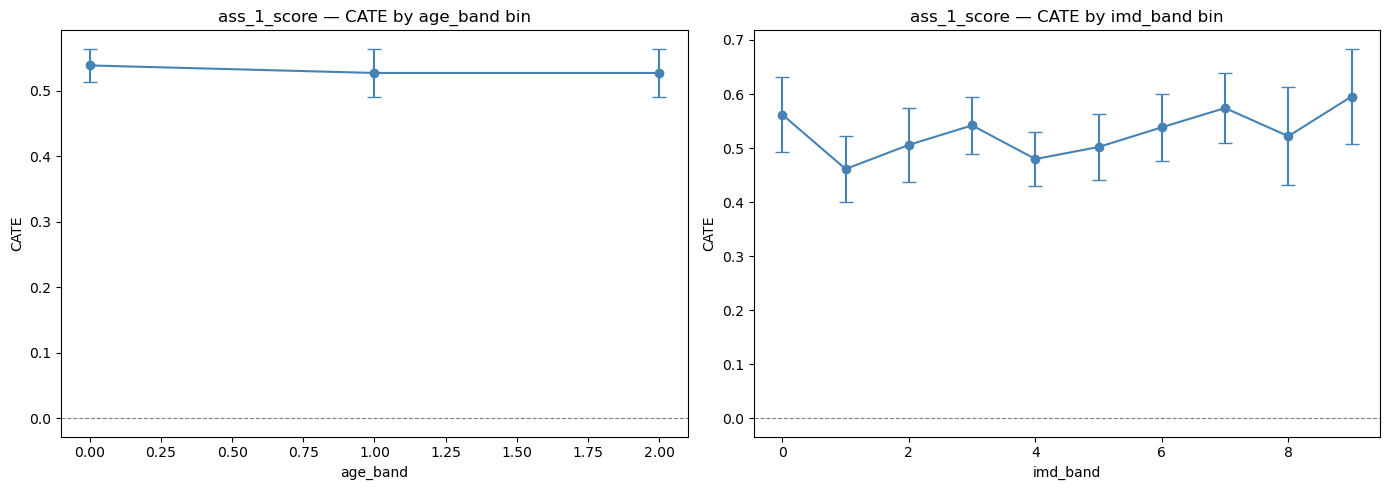

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\DDD\DDD_DAG2_CATE_ass_1_score.png


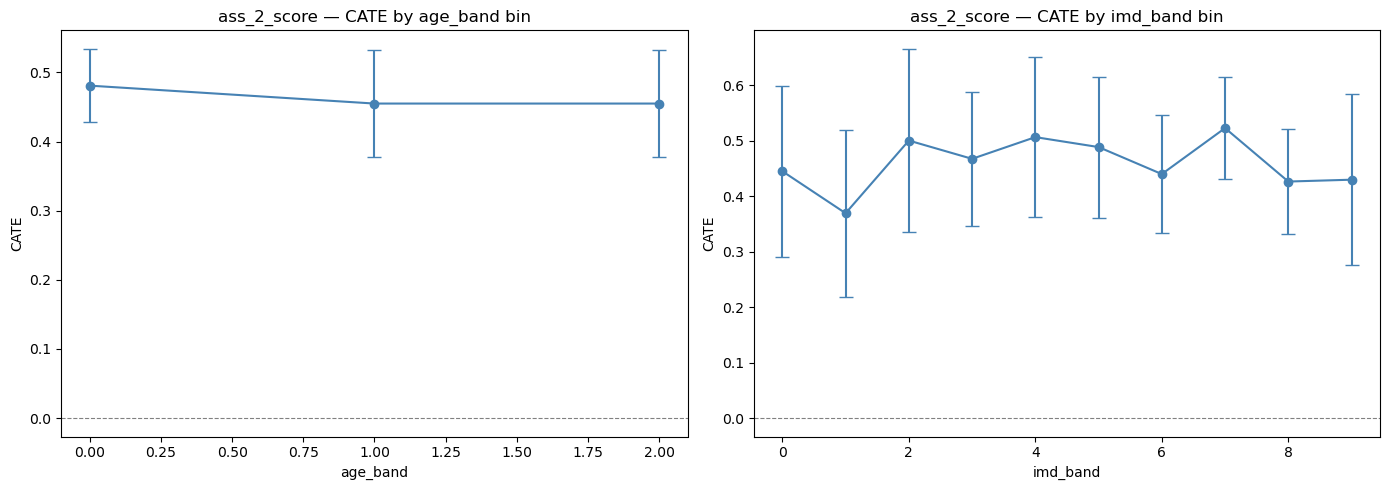

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\DDD\DDD_DAG2_CATE_ass_2_score.png


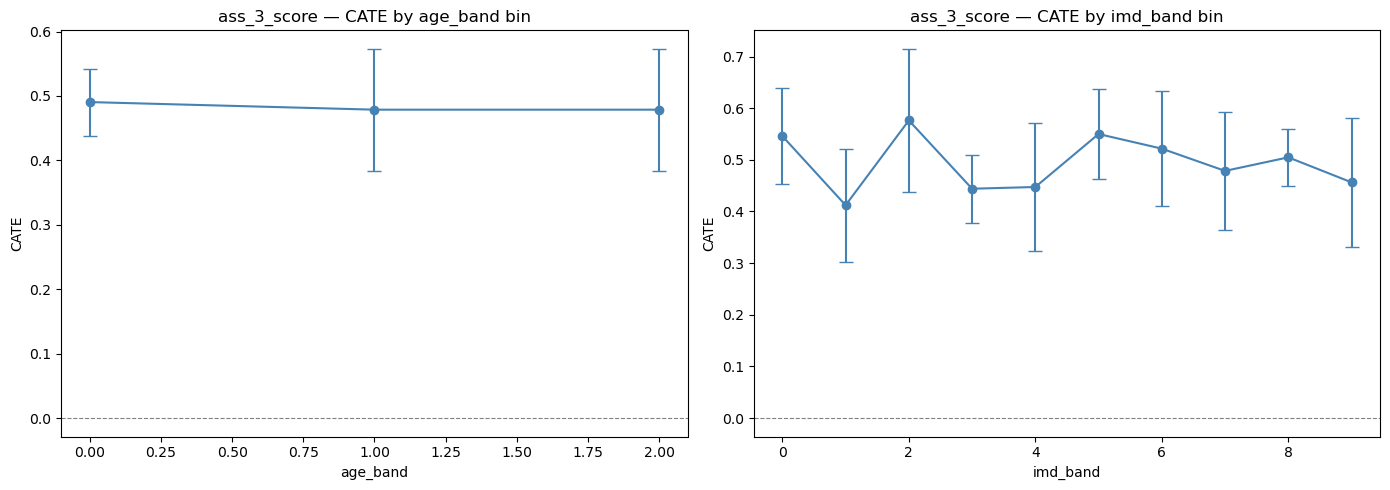

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\DDD\DDD_DAG2_CATE_ass_3_score.png


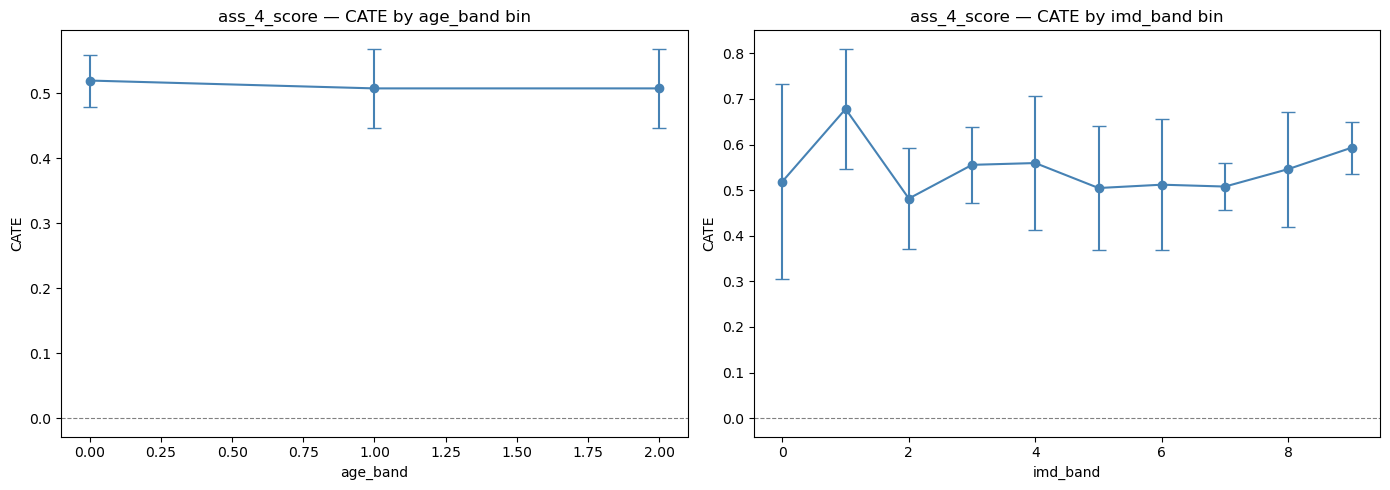

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\DDD\DDD_DAG2_CATE_ass_4_score.png


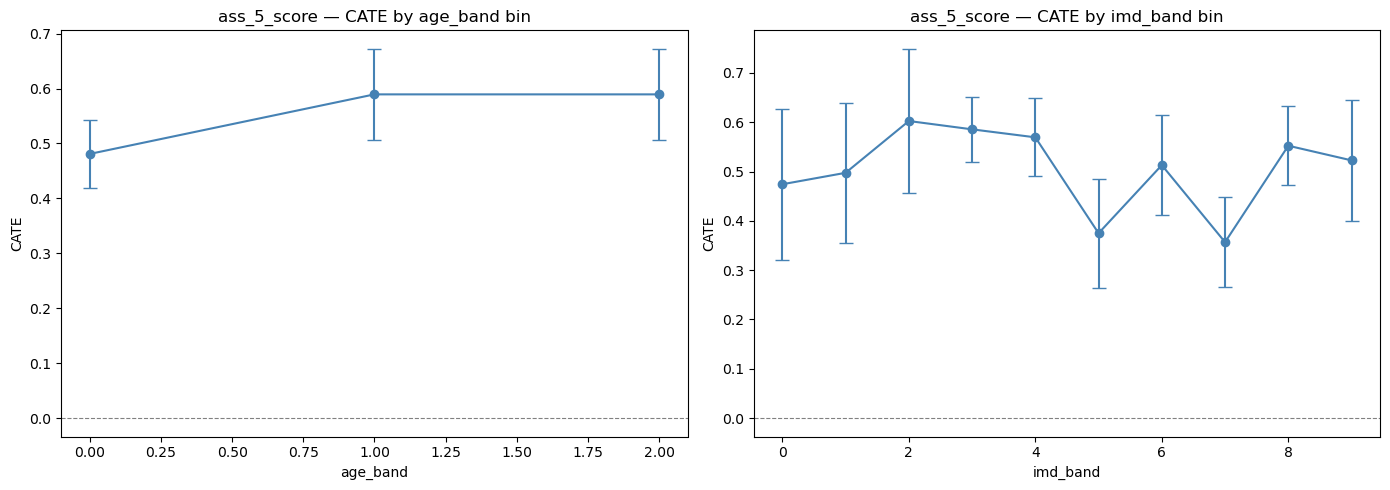

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\DDD\DDD_DAG2_CATE_ass_5_score.png


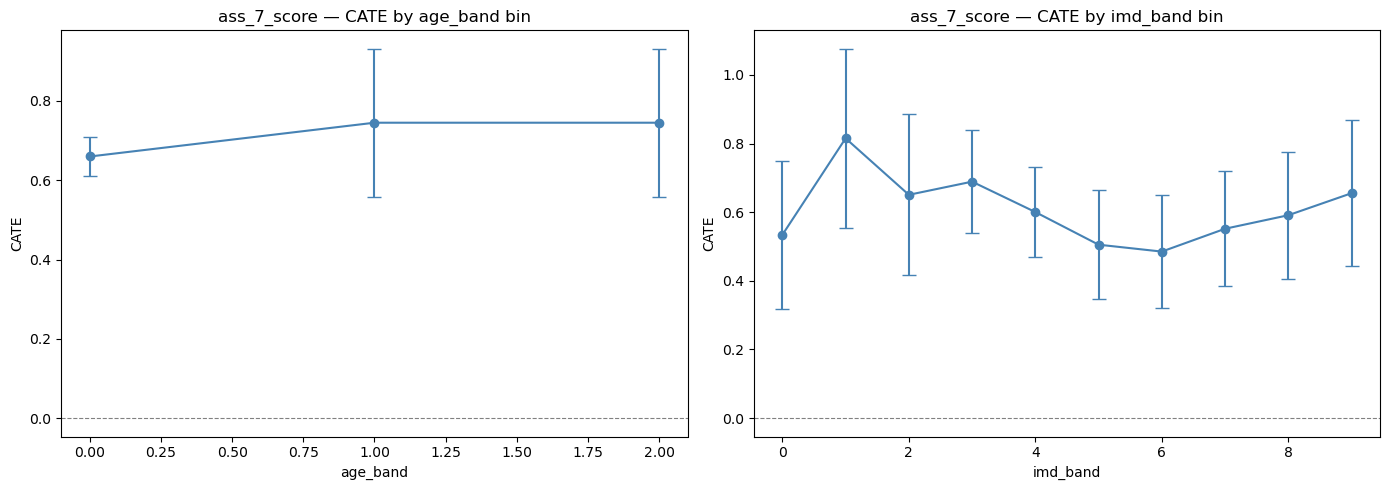

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\DDD\DDD_DAG2_CATE_ass_7_score.png


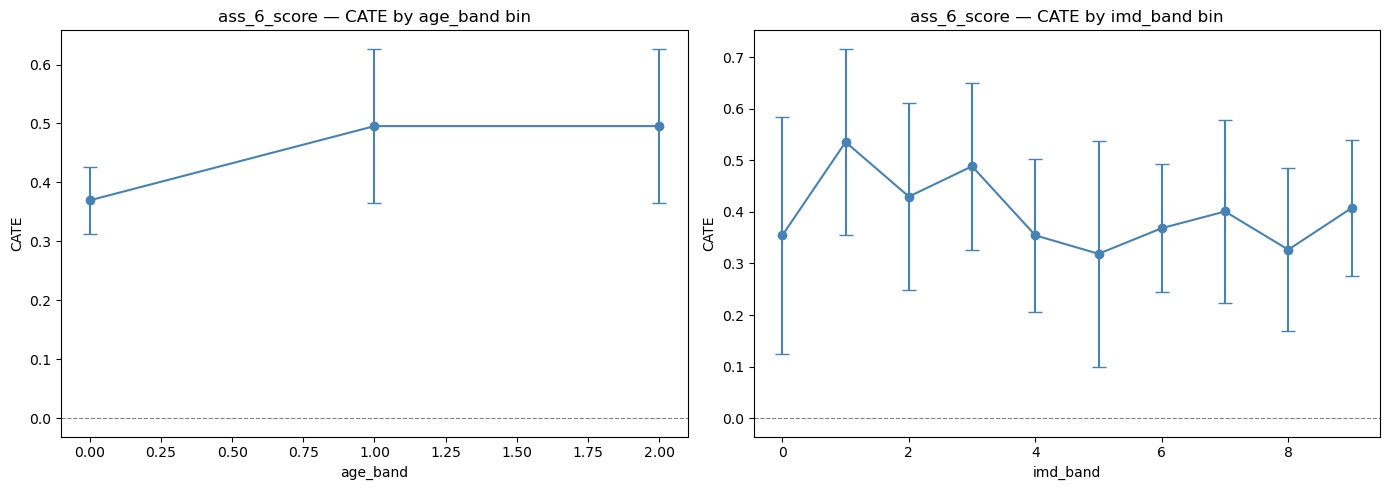

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\DDD\DDD_DAG2_CATE_ass_6_score.png


In [38]:
for treatment in dag2_treatments:
    adj_set = dag2_adjustment_sets[treatment]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, moderator in zip(axes, moderators):
        W_cols = [c for c in adj_set if c != moderator]

        X = df_dag2_cate[[moderator]].values
        T = df_dag2_cate[treatment].values
        Y = df_dag2_cate['final_result'].values
        W = df_dag2_cate[W_cols].values if len(W_cols) > 0 else None

        est = CausalForestDML(random_state=42)
        est.fit(Y, T, X=X, W=W)

        bin_values = sorted(df_dag2_cate[moderator].unique())
        X_bins = np.array(bin_values).reshape(-1, 1)

        point_estimates = est.effect(X_bins)
        lb, ub = est.effect_interval(X_bins, alpha=0.05)
        yerr = np.array([point_estimates - lb, ub - point_estimates])

        ax.errorbar(bin_values, point_estimates, yerr=yerr, fmt='o-', capsize=5, color='steelblue')
        ax.set_xlabel(moderator)
        ax.set_ylabel('CATE')
        ax.set_title(f'{treatment} — CATE by {moderator} bin')
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f"DDD_DAG2_CATE_{treatment}.png")
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()
    print(f"Saved: {save_path}")

## 3-DAG-split ATE heatmap — all treatments across DAG1/DAG2/DAG3

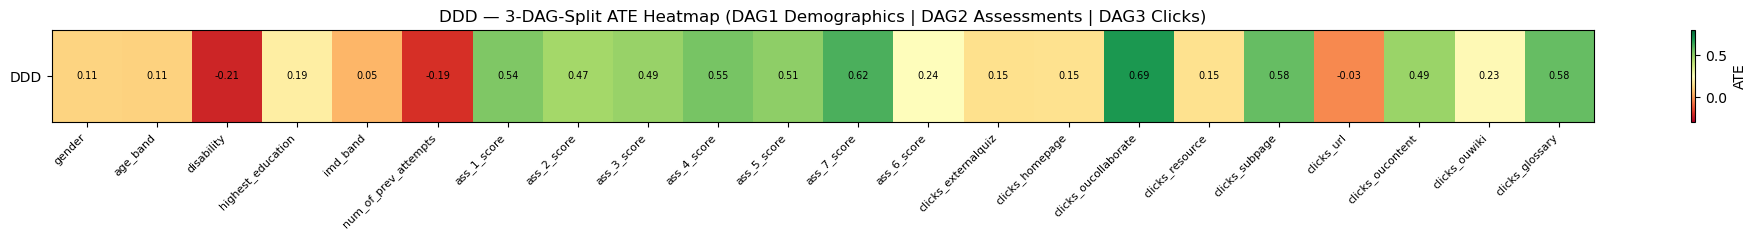

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\DDD\DDD_3DAGSplit_ATE_heatmap.png


In [41]:
all_split_results = pd.concat([dag1_results_df, dag2_results_df, dag3_results_df], ignore_index=True)

heatmap_data = all_split_results.set_index('treatment')[['ATE']].T

plt.figure(figsize=(20, 2.5))
plt.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto', vmin=-0.3, vmax=0.8)
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=45, ha='right', fontsize=8)
plt.yticks([0], ['DDD'])
plt.colorbar(label='ATE')

for i, val in enumerate(heatmap_data.values[0]):
    plt.text(i, 0, f'{val:.2f}', ha='center', va='center', fontsize=7)

plt.title('DDD — 3-DAG-Split ATE Heatmap (DAG1 Demographics | DAG2 Assessments | DAG3 Clicks)')
plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, "DDD_3DAGSplit_ATE_heatmap.png")
plt.savefig(save_path, dpi=150)
plt.show()
plt.close()
print(f"Saved: {save_path}")

## Three-panel DAG-with-ATE overlay — DAG1, DAG2, DAG3 side by side

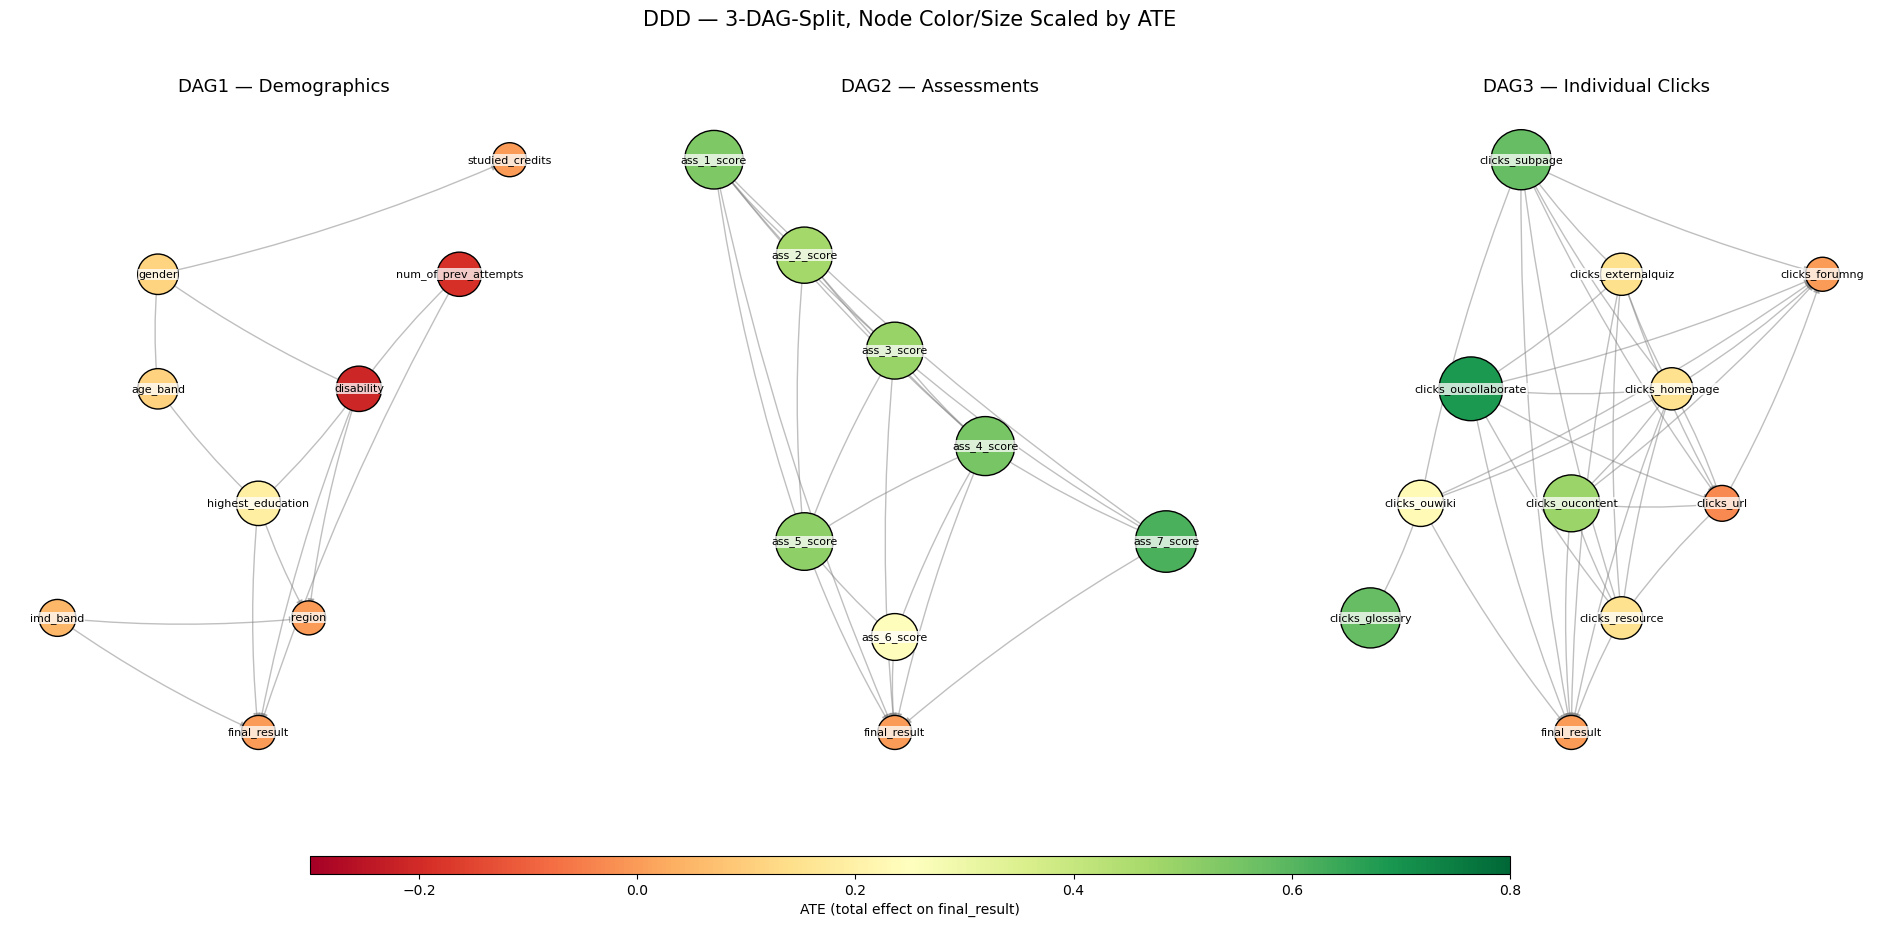

Saved: C:\Users\Disha Sharma\Desktop\Paper_1\RQ2\DDD\DDD_3DAGSplit_DAG_with_ATE.png


In [50]:
pos1 = {
    'gender': (1, 4), 'age_band': (1, 3),
    'highest_education': (2, 2), 'disability': (3, 3),
    'num_of_prev_attempts': (4, 4), 'imd_band': (0, 1),
    'region': (2.5, 1), 'studied_credits': (4.5, 5),
    'final_result': (2, 0),
}

pos2 = {
    'ass_1_score': (1, 5),
    'ass_2_score': (1.5, 4),
    'ass_3_score': (2, 3),
    'ass_4_score': (2.5, 2),
    'ass_5_score': (1.5, 1), 'ass_7_score': (3.5, 1),
    'ass_6_score': (2, 0),
    'final_result': (2, -1),
}

pos3 = {
    'clicks_externalquiz': (2, 4), 'clicks_oucollaborate': (0.5, 3),
    'clicks_subpage': (1, 5), 'clicks_homepage': (2.5, 3),
    'clicks_forumng': (4, 4),
    'clicks_oucontent': (1.5, 2), 'clicks_ouwiki': (0, 2),
    'clicks_resource': (2, 1), 'clicks_url': (3, 2),
    'clicks_glossary': (-0.5, 1),
    'final_result': (1.5, 0),
}

fig, axes = plt.subplots(1, 3, figsize=(24, 9))
ate_lookup_all = all_split_results.set_index('treatment')['ATE'].to_dict()
titles = ['DAG1 — Demographics', 'DAG2 — Assessments', 'DAG3 — Individual Clicks']

for ax, Gx, posx, title in zip(axes, [G1, G2, G3], [pos1, pos2, pos3], titles):
    missing = [n for n in Gx.nodes() if n not in posx]
    if missing:
        print(f"WARNING — missing pos in {title}:", missing)

    node_colors, node_sizes = [], []
    for node in Gx.nodes():
        ate_val = ate_lookup_all.get(node, 0)
        node_colors.append(ate_val)
        node_sizes.append(600 + abs(ate_val) * 2200)

    nx.draw_networkx_edges(Gx, posx, ax=ax, edge_color='gray', arrows=True, arrowsize=10,
                            alpha=0.5, connectionstyle='arc3,rad=0.05')
    nc = nx.draw_networkx_nodes(Gx, posx, ax=ax, node_color=node_colors, node_size=node_sizes,
                                 cmap='RdYlGn', vmin=-0.3, vmax=0.8, edgecolors='black')
    nx.draw_networkx_labels(Gx, posx, ax=ax, font_size=8,
                             bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=0.4))
    ax.set_title(title, fontsize=13)
    ax.axis('off')

cbar_ax = fig.add_axes([0.25, 0.02, 0.5, 0.02])
plt.colorbar(nc, cax=cbar_ax, orientation='horizontal', label='ATE (total effect on final_result)')

plt.suptitle('DDD — 3-DAG-Split, Node Color/Size Scaled by ATE', fontsize=15)
#plt.tight_layout(rect=[0, 0.06, 1, 0.96])
save_path = os.path.join(OUTPUT_DIR, "DDD_3DAGSplit_DAG_with_ATE.png")
plt.savefig(save_path, dpi=150)
plt.show()
plt.close()
print(f"Saved: {save_path}")